In [1]:
# about 5 minutes 15 seconds
from constant_iv_term_structure_engine import constantIVTermStructureEngine

# ticker = ["AAPL", "MSFT", "GOOGL"]
# tickers = open("symbols.txt").read().splitlines()[:100] # test first 50
tickers = open("symbols.txt").read().splitlines()

engine = constantIVTermStructureEngine(ticker=tickers)
result = engine.run()

Running 1000 tickers in parallel with 16 cores...
[NVDA] [1/11] Fetching equity data...
[AVGO] [1/11] Fetching equity data...
[MU] [1/11] Fetching equity data...
[AMD] [1/11] Fetching equity data...
[AAPL] [1/11] Fetching equity data...
[TSM] [1/11] Fetching equity data...
[INTC] [1/11] Fetching equity data...
[AMZN] [1/11] Fetching equity data...
[GOOG] [1/11] Fetching equity data...
[PLTR] [1/11] Fetching equity data...
[NFLX] [1/11] Fetching equity data...
[GOOGL] [1/11] Fetching equity data...
[TSLA] [1/11] Fetching equity data...
[META] [1/11] Fetching equity data...
[UNH] [1/11] Fetching equity data...
[ORCL] [1/11] Fetching equity data...
[META]         Equity rows: 1088
[META] [2/11] Fetching options data...
[PLTR]         Equity rows: 1366
[PLTR] [2/11] Fetching options data...
[GOOGL]         Equity rows: 3001
[GOOGL] [2/11] Fetching options data...
[INTC]         Equity rows: 5660
[INTC] [2/11] Fetching options data...
[GOOG]         Equity rows: 5423
[GOOG] [2/11] Fetching 

In [2]:
result

ticker,expirDate,trade_date,cOpra,pOpra,cVolu,pVolu,cOi,pOi,min_leg_volume,total_volume,min_leg_oi,total_oi,dollar_vol,SLOPE,IVRV_SLOPE,straddle_price_bid,straddle_price_ask,straddle_price_mid,spread_abs,spread_pct_mid,wret,q_slope
str,datetime[μs],date,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32
"""PLTR""",2026-06-18 00:00:00,2025-01-02,"""PLTR260618C00085000""","""PLTR260618P00085000""",29.0,0.0,605.0,193.0,0.0,29.0,193.0,798.0,1.5504e11,-0.005871,0.02542,45.75,48.1,46.925,2.35,0.05008,-0.019751,1
"""PLTR""",2026-06-18 00:00:00,2025-01-03,"""PLTR260618C00085000""","""PLTR260618P00085000""",16.0,0.0,602.0,193.0,0.0,16.0,193.0,795.0,1.5695e11,-0.000624,0.035246,47.15,48.45,47.8,1.3,0.027197,-0.049536,2
"""PLTR""",2026-06-18 00:00:00,2025-01-06,"""PLTR260618C00085000""","""PLTR260618P00085000""",27.0,0.0,611.0,193.0,0.0,27.0,193.0,804.0,1.5782e11,-0.005839,0.018201,46.05,49.4,47.725,3.35,0.070194,-0.156883,1
"""PLTR""",2026-06-18 00:00:00,2025-01-07,"""PLTR260618C00075000""","""PLTR260618P00075000""",114.0,31.0,921.0,135.0,31.0,145.0,135.0,1056.0,1.5821e11,-0.00454,0.038632,41.65,42.7,42.175,1.05,0.024896,-0.02459,1
"""PLTR""",2026-06-18 00:00:00,2025-01-08,"""PLTR260618C00075000""","""PLTR260618P00075000""",44.0,51.0,898.0,144.0,44.0,95.0,144.0,1042.0,1.5966e11,-0.004095,0.031403,41.65,42.25,41.95,0.6,0.014303,-0.080473,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""CMC""",2026-03-20 00:00:00,2026-03-03,"""CMC260320C00072500""","""CMC260320P00072500""",0.0,0.0,10.0,38.0,0.0,0.0,10.0,48.0,1.9398e9,-0.085085,-0.203856,5.3,5.85,5.575,0.55,0.098655,-0.145299,2
"""CMC""",2026-03-20 00:00:00,2026-03-04,"""CMC260320C00072500""","""CMC260320P00072500""",1.0,7.0,10.0,38.0,1.0,8.0,10.0,48.0,1.9071e9,-0.078687,-0.172151,5.0,5.25,5.125,0.25,0.04878,-0.142857,2
"""CMC""",2026-03-20 00:00:00,2026-03-05,"""CMC260320C00067500""","""CMC260320P00067500""",0.0,0.0,53.0,33.0,0.0,0.0,33.0,86.0,1.9227e9,-0.121103,-0.247925,4.5,5.7,5.1,1.2,0.235294,-0.315789,1


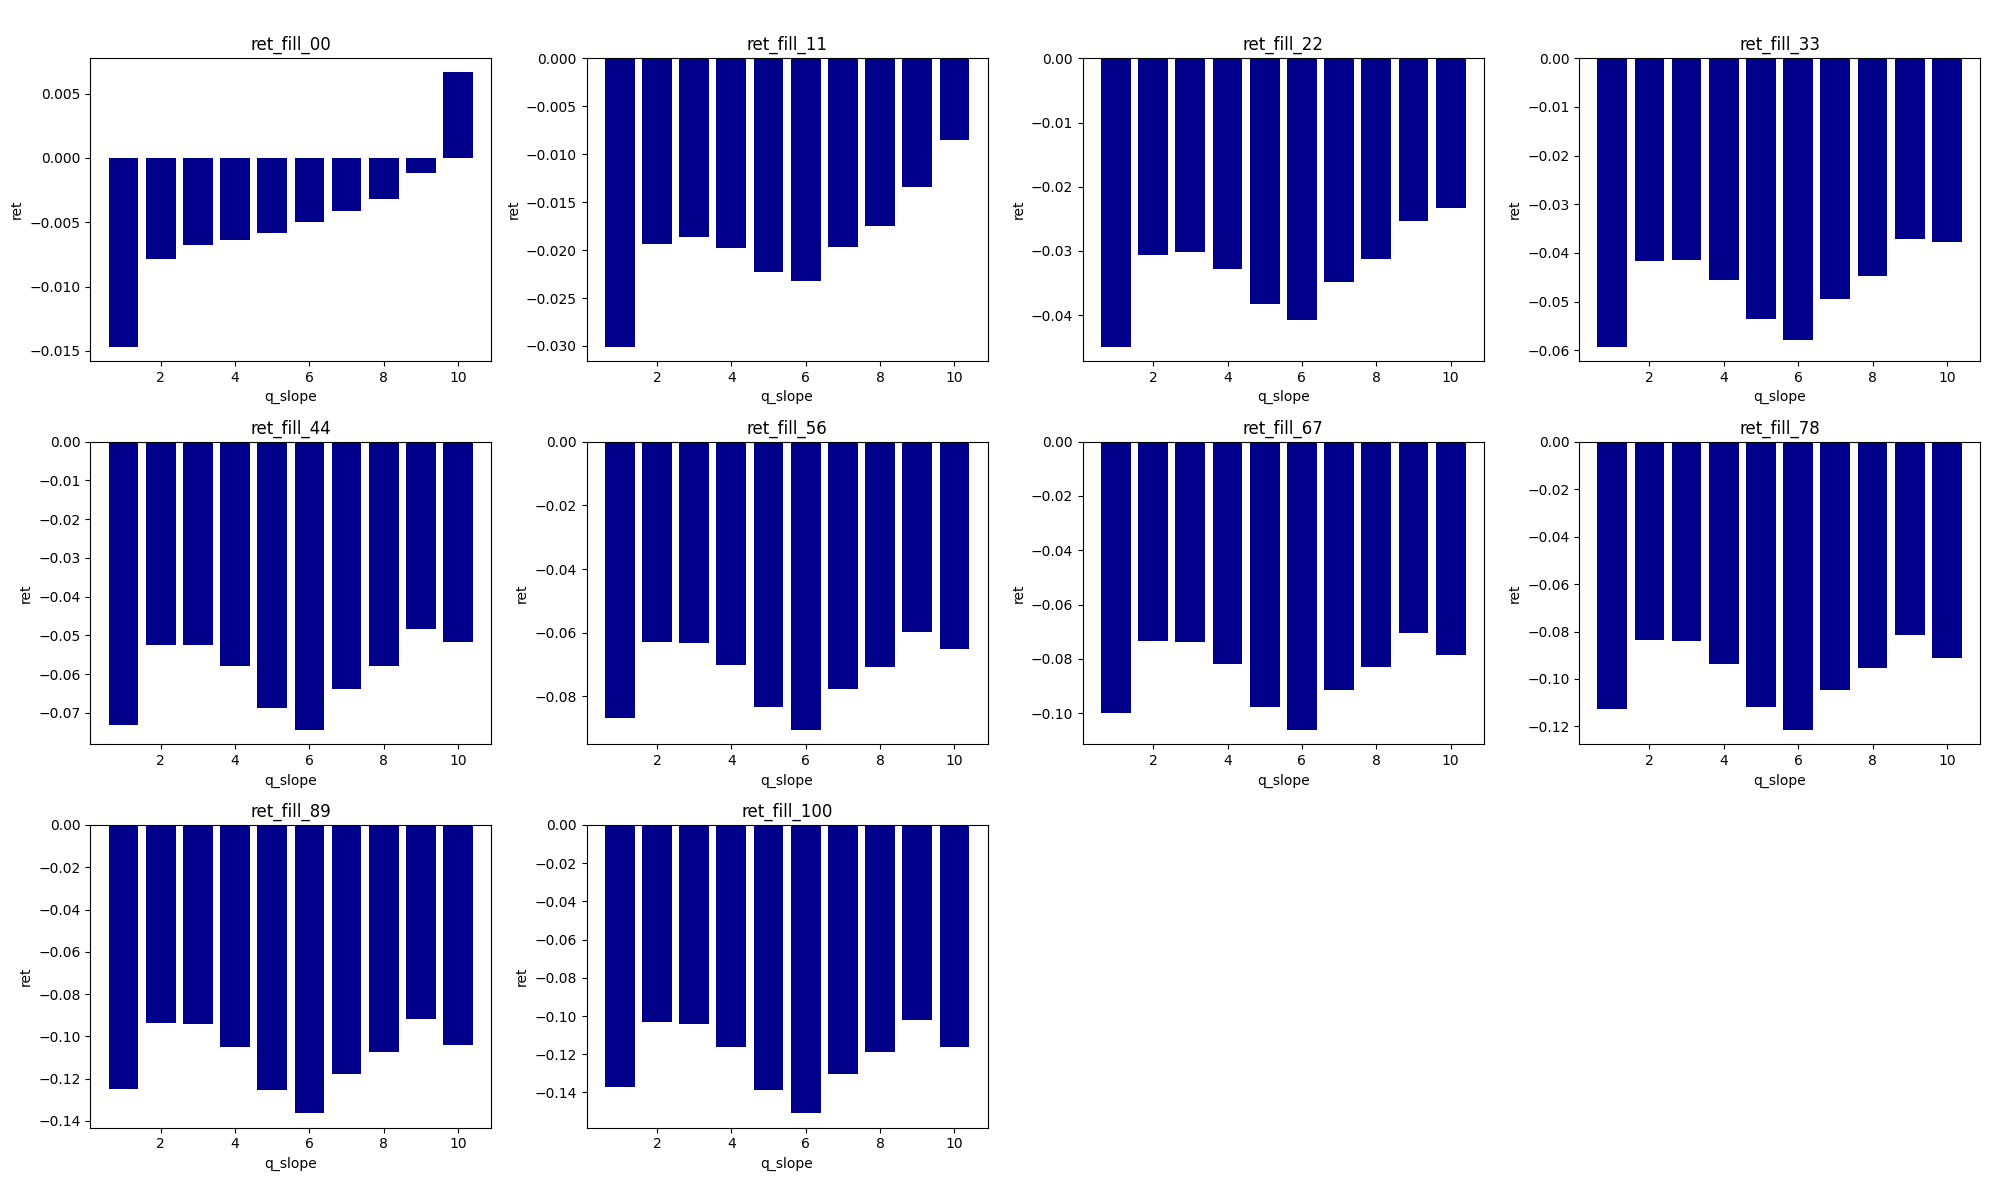

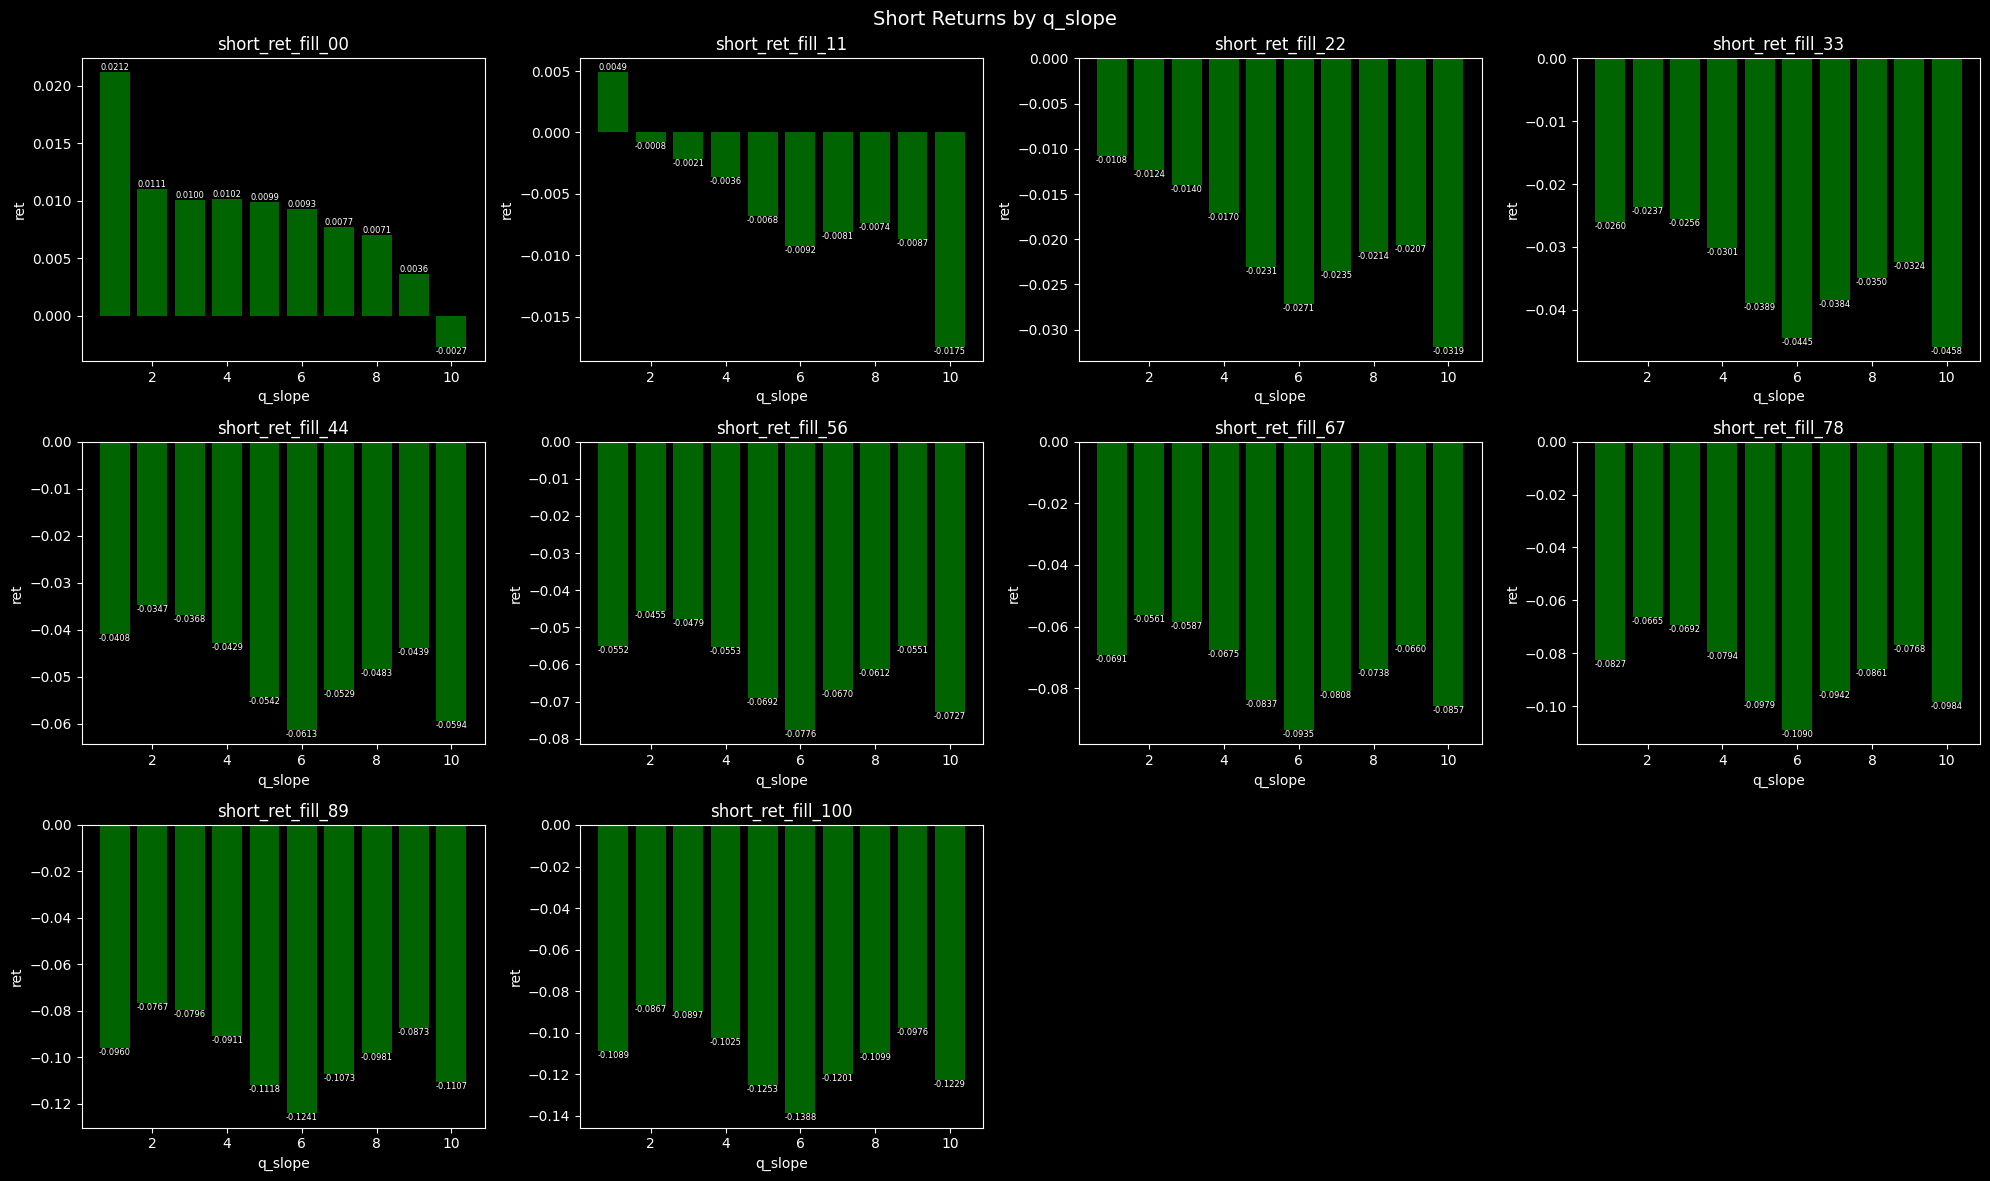

In [3]:
# 2. Compute trade execution returns
next_df = engine.trade_execution(result)

# 3. Plot
engine.plot_long_returns(next_df)
engine.plot_short_returns(next_df)

---

In [6]:
import polars as pl
import numpy as np
import os
from dotenv import load_dotenv

load_dotenv(override=True)

def trade_execution(df: pl.DataFrame) -> pl.DataFrame:
    """
    Compute next-day straddle prices and returns across an execution quality grid.

    SPREAD_CHOICE (from .env):
        - PARTIAL: slippage from mid toward bid/ask (half spread)
        - FULL: slippage across the full bid-ask spread

    For each fill level f in [0, 1]:
        PARTIAL:
            - f=0: execute at mid, f=1: execute at bid/ask
        FULL:
            - f=0: worst (long buys at ask, sells at next_bid; short sells at bid, buys at next_ask)
            - f=1: best (long buys at bid, sells at next_ask; short sells at ask, buys at next_bid)

    Input:
        df (pl.DataFrame): Must contain columns: ticker, expirDate, trade_date, cOpra, pOpra,
                           straddle_price_bid, straddle_price_ask, straddle_price_mid, q_slope

    Output:
        pl.DataFrame: Original columns plus next_mid, next_bid, next_ask,
                      ret_fill_XX and short_ret_fill_XX for each fill level
    """
    spread_choice = os.getenv("SPREAD_CHOICE", "PARTIAL")

    # select relevant columns
    df = df.select("ticker", "expirDate", "trade_date", "cOpra", "pOpra", "straddle_price_bid", "straddle_price_ask", "straddle_price_mid", "q_slope")

    # Compute next-day straddle prices per ticker
    df = df.with_columns([
        pl.col("straddle_price_mid").shift(-1).over("ticker").alias("next_mid"),
        pl.col("straddle_price_bid").shift(-1).over("ticker").alias("next_bid"),
        pl.col("straddle_price_ask").shift(-1).over("ticker").alias("next_ask"),
    ])

    # Compute returns across execution quality grid
    n_grid = int(os.getenv("N_GRID"))
    fill_grid = np.linspace(0, 1, n_grid)

    ret_cols = []
    short_ret_cols = []

    for f in fill_grid:
        fill_pct = int(round(f * 100))
        ret_col = f"ret_fill_{fill_pct:02d}"
        short_ret_col = f"short_ret_fill_{fill_pct:02d}"

        if spread_choice == "FULL":
            # Long: f=0 buy at ask (worst), f=1 buy at bid (best)
            entry_long = pl.col("straddle_price_ask") - f * (pl.col("straddle_price_ask") - pl.col("straddle_price_bid"))
            # f=0 sell at next_bid (worst), f=1 sell at next_ask (best)
            exit_long = pl.col("next_bid") + f * (pl.col("next_ask") - pl.col("next_bid"))

            # Short: f=0 sell at bid (worst), f=1 sell at ask (best)
            entry_short = pl.col("straddle_price_bid") + f * (pl.col("straddle_price_ask") - pl.col("straddle_price_bid"))
            # f=0 buy back at next_ask (worst), f=1 buy back at next_bid (best)
            exit_short = pl.col("next_ask") - f * (pl.col("next_ask") - pl.col("next_bid"))
        else:
            # Long: buy at mid + slippage toward ask, sell at next_mid - slippage toward next_bid
            entry_long = pl.col("straddle_price_mid") + f * (pl.col("straddle_price_ask") - pl.col("straddle_price_mid"))
            exit_long = pl.col("next_mid") - f * (pl.col("next_mid") - pl.col("next_bid"))

            # Short: sell at mid - slippage toward bid, buy back at next_mid + slippage toward next_ask
            entry_short = pl.col("straddle_price_mid") - f * (pl.col("straddle_price_mid") - pl.col("straddle_price_bid"))
            exit_short = pl.col("next_mid") + f * (pl.col("next_ask") - pl.col("next_mid"))

        ret_cols.append(
            pl.when(entry_long.abs() > 1e-10)
            .then(exit_long / entry_long - 1)
            .otherwise(None)
            .alias(ret_col)
        )

        short_ret_cols.append(
            pl.when(exit_short.abs() > 1e-10)
            .then(entry_short / exit_short - 1)
            .otherwise(None)
            .alias(short_ret_col)
        )

    df = df.with_columns(ret_cols + short_ret_cols)
    return df

next_df = trade_execution(result)
next_df

ticker,expirDate,trade_date,cOpra,pOpra,straddle_price_bid,straddle_price_ask,straddle_price_mid,q_slope,next_mid,next_bid,next_ask,ret_fill_00,ret_fill_11,ret_fill_22,ret_fill_33,ret_fill_44,ret_fill_56,ret_fill_67,ret_fill_78,ret_fill_89,ret_fill_100,short_ret_fill_00,short_ret_fill_11,short_ret_fill_22,short_ret_fill_33,short_ret_fill_44,short_ret_fill_56,short_ret_fill_67,short_ret_fill_78,short_ret_fill_89,short_ret_fill_100
str,datetime[μs],date,str,str,f64,f64,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""PLTR""",2026-06-18 00:00:00,2025-01-02,"""PLTR260618C00085000""","""PLTR260618P00085000""",45.75,48.1,46.925,1,47.8,47.15,48.45,0.018647,0.014286,0.009949,0.005636,0.001347,-0.002919,-0.007162,-0.011381,-0.015577,-0.019751,-0.018305,-0.022514,-0.026709,-0.030892,-0.035062,-0.03922,-0.043366,-0.047499,-0.051619,-0.055728
"""PLTR""",2026-06-18 00:00:00,2025-01-03,"""PLTR260618C00085000""","""PLTR260618P00085000""",47.15,48.45,47.8,2,47.725,46.05,49.4,-0.001569,-0.006963,-0.012341,-0.017702,-0.023048,-0.028377,-0.03369,-0.038988,-0.04427,-0.049536,0.001572,-0.003827,-0.009183,-0.014498,-0.019772,-0.025006,-0.0302,-0.035354,-0.04047,-0.045547
"""PLTR""",2026-06-18 00:00:00,2025-01-06,"""PLTR260618C00085000""","""PLTR260618P00085000""",46.05,49.4,47.725,1,42.175,41.65,42.7,-0.116291,-0.120942,-0.125556,-0.130135,-0.134678,-0.139187,-0.143661,-0.148102,-0.152509,-0.156883,0.131595,0.125625,0.119672,0.113735,0.107814,0.10191,0.096022,0.09015,0.084294,0.078454
"""PLTR""",2026-06-18 00:00:00,2025-01-07,"""PLTR260618C00075000""","""PLTR260618P00075000""",41.65,42.7,42.175,1,41.95,41.65,42.25,-0.005335,-0.007498,-0.009655,-0.011806,-0.013952,-0.016091,-0.018225,-0.020352,-0.022474,-0.02459,0.005364,0.003176,0.000992,-0.001189,-0.003366,-0.00554,-0.007711,-0.009878,-0.012041,-0.014201
"""PLTR""",2026-06-18 00:00:00,2025-01-08,"""PLTR260618C00075000""","""PLTR260618P00075000""",41.65,42.25,41.95,1,39.725,38.85,40.6,-0.053039,-0.056107,-0.05917,-0.062228,-0.065281,-0.068329,-0.071372,-0.074411,-0.077444,-0.080473,0.05601,0.052595,0.049196,0.045814,0.042449,0.039099,0.035766,0.032449,0.029148,0.025862
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""CMC""",2026-03-20 00:00:00,2026-03-03,"""CMC260320C00072500""","""CMC260320P00072500""",5.3,5.85,5.575,2,5.125,5.0,5.25,-0.080717,-0.088206,-0.095614,-0.102941,-0.11019,-0.117362,-0.124457,-0.131478,-0.138425,-0.145299,0.087805,0.078919,0.070081,0.06129,0.052547,0.04385,0.0352,0.026596,0.018037,0.009524
"""CMC""",2026-03-20 00:00:00,2026-03-04,"""CMC260320C00072500""","""CMC260320P00072500""",5.0,5.25,5.125,2,5.1,4.5,5.7,-0.004878,-0.020541,-0.036119,-0.051613,-0.067024,-0.082353,-0.0976,-0.112766,-0.127851,-0.142857,0.004902,-0.010753,-0.026008,-0.040881,-0.055383,-0.06953,-0.083333,-0.096806,-0.109961,-0.122807
"""CMC""",2026-03-20 00:00:00,2026-03-05,"""CMC260320C00067500""","""CMC260320P00067500""",4.5,5.7,5.1,1,4.5,3.9,5.1,-0.117647,-0.141935,-0.165605,-0.188679,-0.21118,-0.233129,-0.254545,-0.275449,-0.295858,-0.315789,0.133333,0.10219,0.071942,0.042553,0.013986,-0.013793,-0.040816,-0.067114,-0.092715,-0.117647


# OBSERVATIONS

1. for implied term structure using `SLOPE` and frequency set as `daily`, only the 10th decile gives the best returns

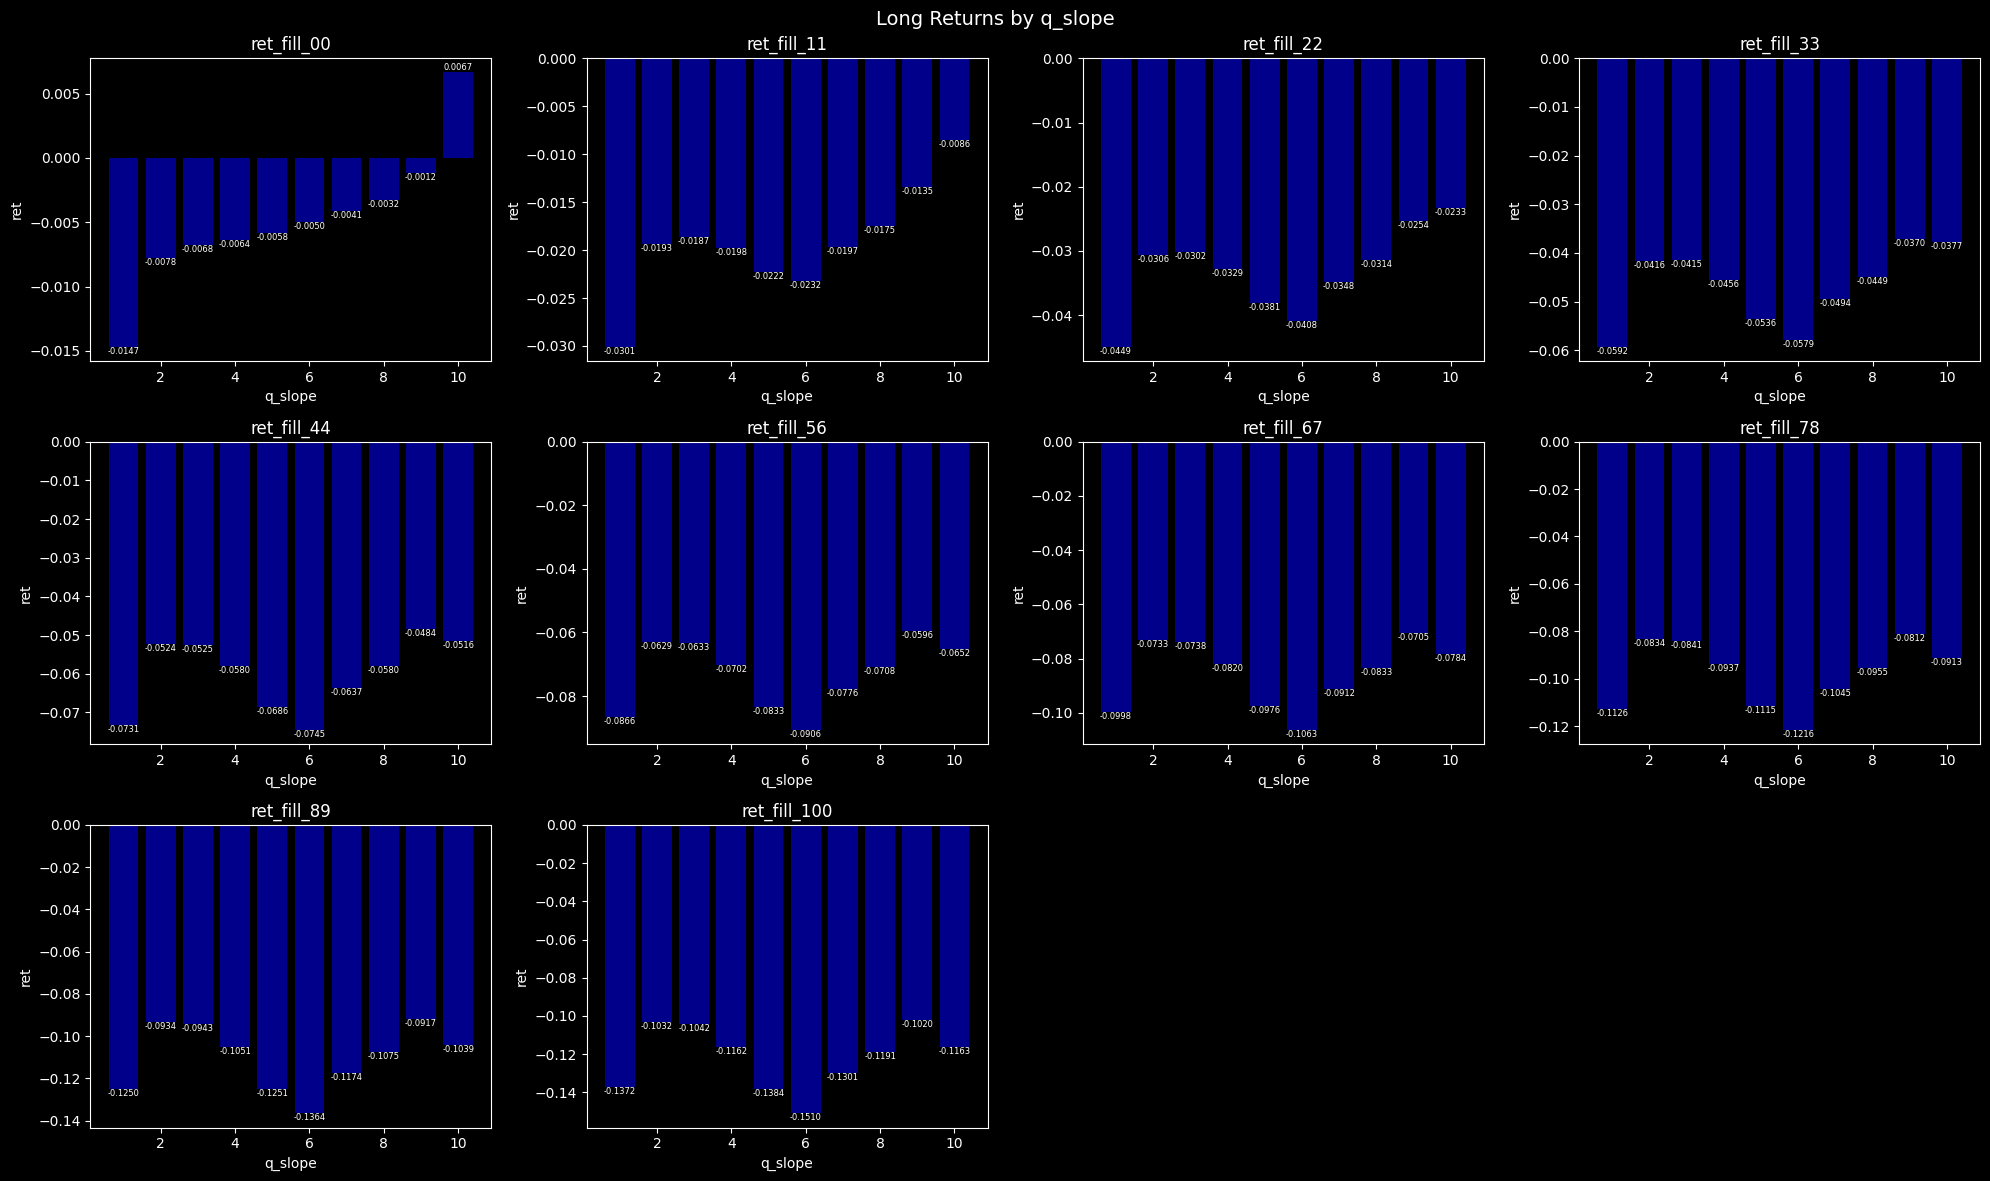

In [7]:
from matplotlib import pyplot as plt
import math

target_rank_column = "q_slope"
n_grid = int(os.getenv("N_GRID"))
fill_levels = [f"{int(round(f * 100)):02d}" for f in np.linspace(0, 1, n_grid)]

ncols = 4
nrows = math.ceil(len(fill_levels) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
plt.style.use('dark_background')
fig.suptitle(f"Long Returns by {target_rank_column}", fontsize=14)

for i, fill in enumerate(fill_levels):
    ax = axes[i // ncols][i % ncols]
    target_return_column = f"ret_fill_{fill}"

    data = next_df.group_by(target_rank_column).agg(
        pl.col(target_return_column).mean().alias("ret")
    ).sort(target_rank_column)

    bars = ax.bar(data[target_rank_column], data["ret"], color="darkblue")
    ax.bar_label(bars, fmt="%.4f", fontsize=6)
    ax.set_title(target_return_column)
    ax.set_xlabel(target_rank_column)
    ax.set_ylabel("ret")

# hide unused subplots
for j in range(len(fill_levels), nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)

plt.tight_layout()
plt.show()

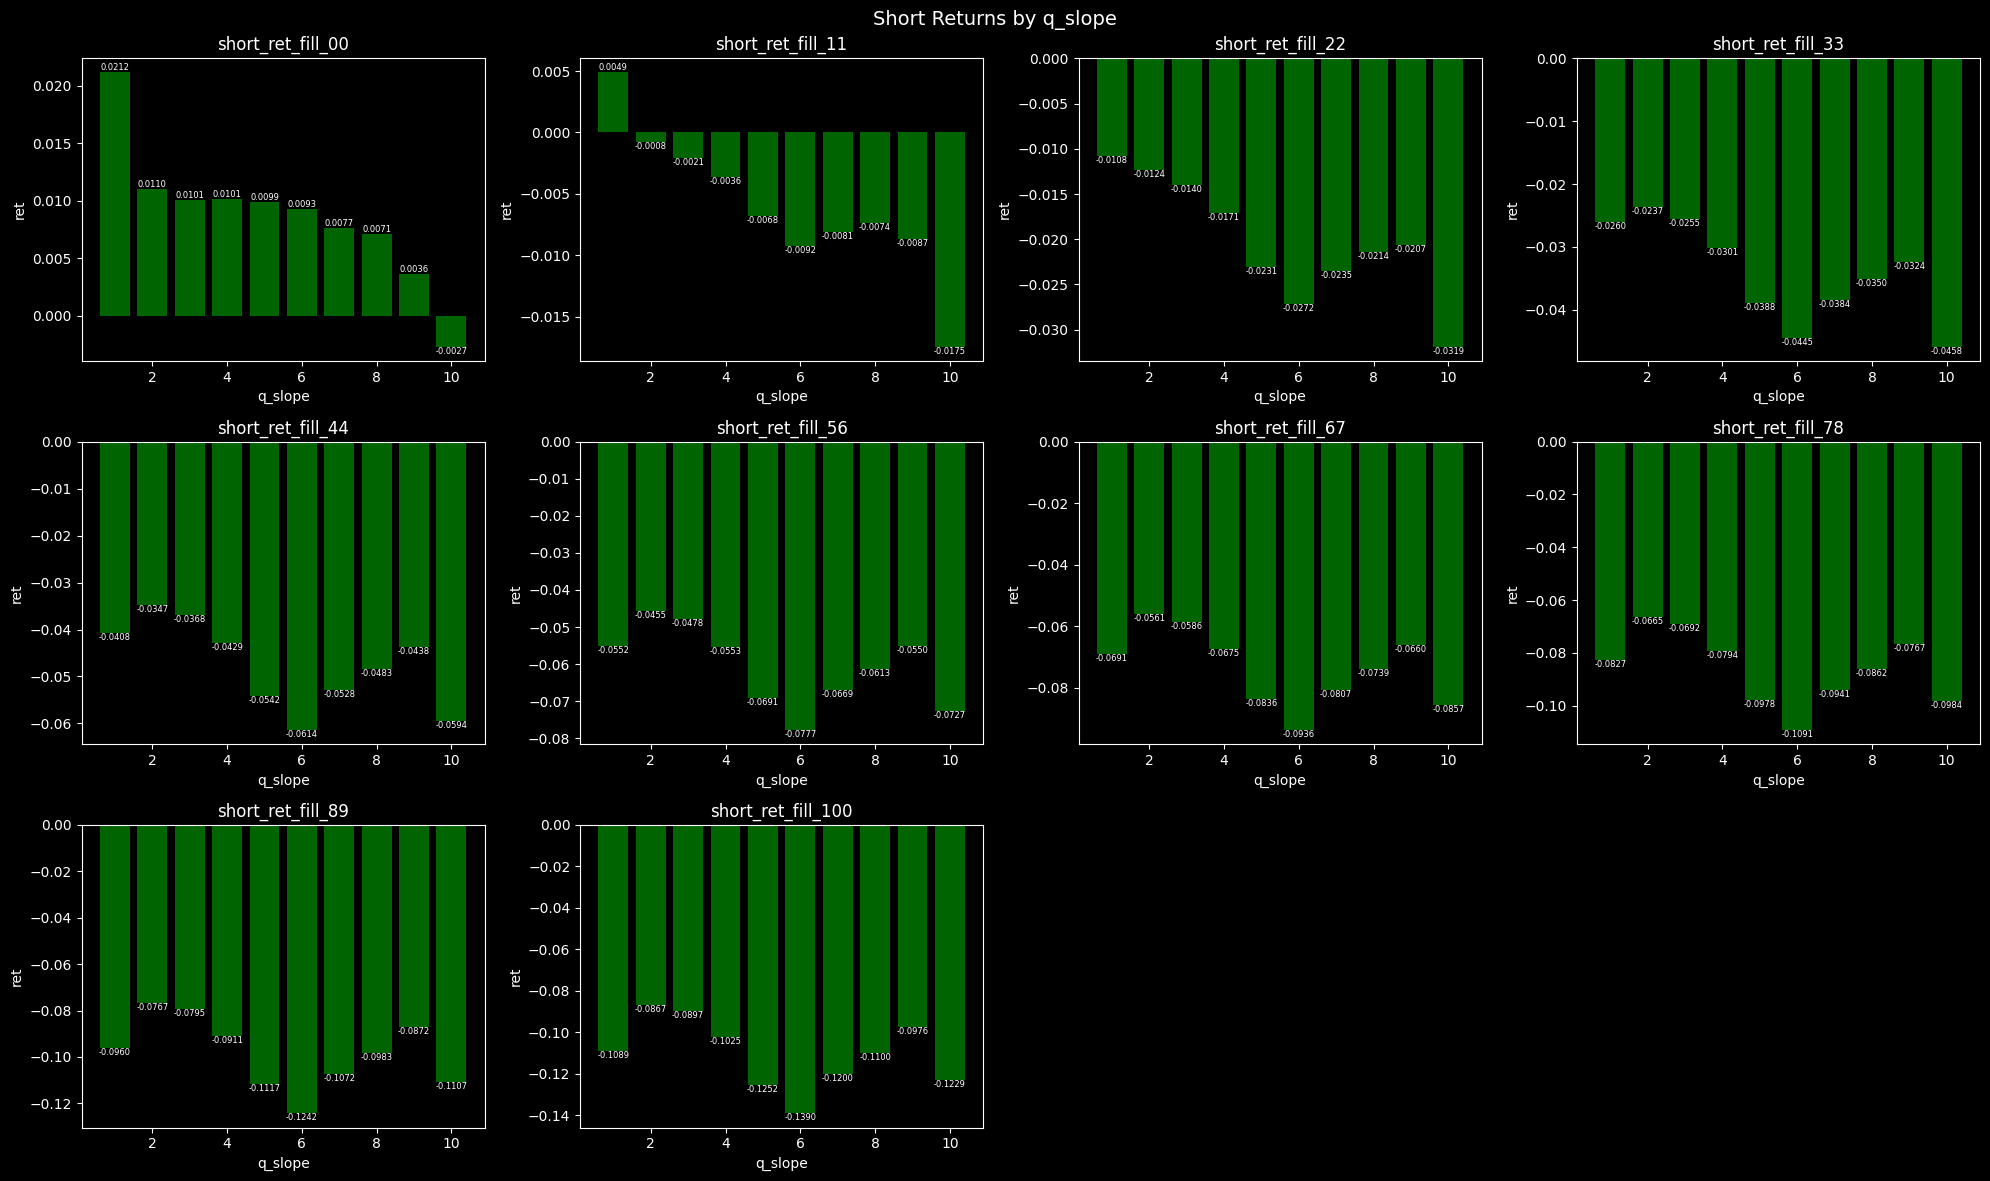

In [8]:
from matplotlib import pyplot as plt
import math

target_rank_column = "q_slope"
n_grid = int(os.getenv("N_GRID"))
fill_levels = [f"{int(round(f * 100)):02d}" for f in np.linspace(0, 1, n_grid)]

ncols = 4
nrows = math.ceil(len(fill_levels) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
plt.style.use('dark_background')
fig.suptitle(f"Short Returns by {target_rank_column}", fontsize=14)

for i, fill in enumerate(fill_levels):
    ax = axes[i // ncols][i % ncols]
    target_return_column = f"short_ret_fill_{fill}"

    data = next_df.group_by(target_rank_column).agg(
        pl.col(target_return_column).mean().alias("ret")
    ).sort(target_rank_column)

    bars = ax.bar(data[target_rank_column], data["ret"], color="darkgreen")
    ax.bar_label(bars, fmt="%.4f", fontsize=6)
    ax.set_title(target_return_column)
    ax.set_xlabel(target_rank_column)
    ax.set_ylabel("ret")

# hide unused subplots
for j in range(len(fill_levels), nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)

plt.tight_layout()
plt.show()